# 03 — Customer Segmentation (RFM + KMeans)

## RFM là gì?
RFM là kỹ thuật phân khúc khách hàng kinh điển trong retail/marketing analytics, dựa trên 3 chỉ số:

| Chỉ số | Ý nghĩa | Trong project này |
|---|---|---|
| **Recency** | Khách mua gần đây nhất cách bao lâu | Số ngày từ đơn cuối đến ngày tham chiếu |
| **Frequency** | Khách mua bao nhiêu lần | Số đơn `delivered` duy nhất |
| **Monetary** | Khách chi bao nhiêu tiền | Tổng `total_order_value` |

**Trực giác:** khách hàng tốt nhất là khách **mua gần đây (Recency thấp), mua thường xuyên
(Frequency cao), và chi nhiều tiền (Monetary cao)**. KMeans nhóm khách hàng có 3 chỉ số này
tương đồng nhau lại thành từng cluster.

**Cấu trúc notebook:** RFM creation → Scaling → Elbow → Silhouette → KMeans → Cluster Statistics
→ Radar Chart → PCA Visualization → Đặt tên cluster → Business Recommendation cho từng cluster.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.feature_engineering import run as compute_rfm
from src.config import RANDOM_STATE, KMEANS_N_INIT

sns.set_style('whitegrid')

## 1. RFM Creation
Gọi thẳng hàm đã viết trong `src/feature_engineering.py` — logic RFM chỉ định nghĩa 1 nơi duy nhất.

In [2]:
rfm = compute_rfm()
print(rfm.shape)
rfm.head()

2026-08-09 19:59:49 | INFO     | src.database | Created SQLAlchemy engine for PostgreSQL.
2026-08-09 19:59:49 | INFO     | src.feature_engineering | Reading customer_order_base view ...
2026-08-09 19:59:50 | INFO     | src.feature_engineering | Using reference date: 2018-08-30 15:00:37
2026-08-09 19:59:55 | INFO     | src.feature_engineering | Computed RFM for 93,358 unique customers.
2026-08-09 19:59:55 | INFO     | src.feature_engineering | Saved RFM features to D:\Retail Customer Intelligence Platform\data\processed\customer_features.csv


(93358, 4)


,customer_unique_id,recency_days,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [3]:
rfm[['recency_days', 'frequency', 'monetary']].describe()

,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


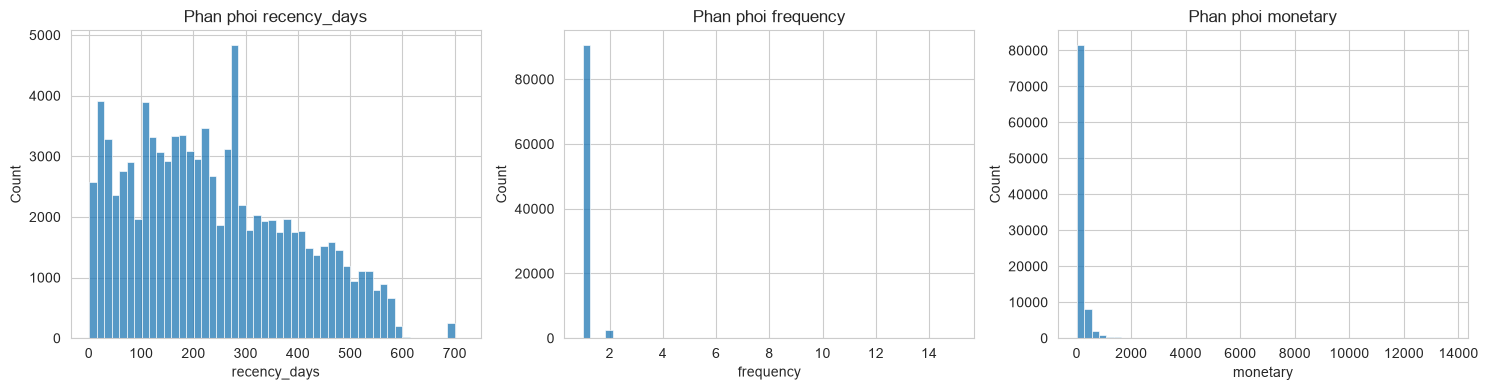

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['recency_days', 'frequency', 'monetary']):
    sns.histplot(rfm[col], bins=50, ax=ax)
    ax.set_title(f'Phan phoi {col}')
plt.tight_layout()
plt.show()

**Nhận xét:** `frequency` và `monetary` thường lệch phải mạnh (đa số khách mua 1 lần, số ít mua
nhiều) — đây chính là lý do cần StandardScaler trước khi đưa vào KMeans.

## 2. Scaling
KMeans dùng khoảng cách Euclidean, nên bắt buộc phải scale — nếu không, `monetary` (đơn vị tiền,
range hàng trăm/nghìn) sẽ lấn át hoàn toàn `frequency` (range 1-10) trong phép tính khoảng cách.

In [5]:
FEATURE_COLUMNS = ['recency_days', 'frequency', 'monetary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[FEATURE_COLUMNS])

print('Truoc scale - mean:', rfm[FEATURE_COLUMNS].mean().values)
print('Sau scale - mean (phai gan 0):', X_scaled.mean(axis=0))
print('Sau scale - std (phai gan 1):', X_scaled.std(axis=0))

Truoc scale - mean: [237.94177253   1.03341974 165.19700261]
Sau scale - mean (phai gan 0): [-2.34417150e-17 -1.90273660e-18  1.08075439e-17]
Sau scale - std (phai gan 1): [1. 1. 1.]


## 3. Elbow Method — chọn k bằng inertia

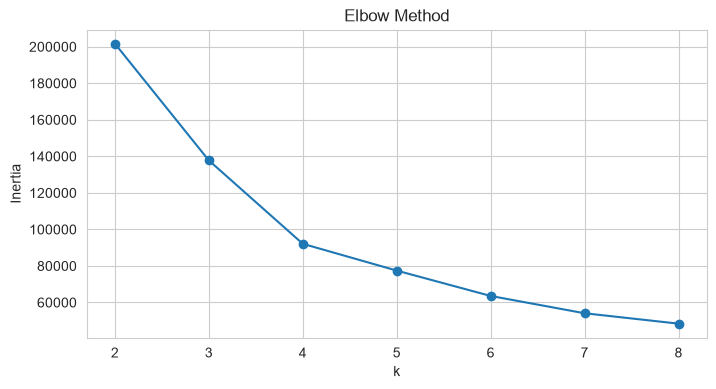

In [6]:
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 4. Silhouette Score — xác nhận k tốt nhất

k=2 -> silhouette=0.7389
k=3 -> silhouette=0.4560
k=4 -> silhouette=0.4886
k=5 -> silhouette=0.4187
k=6 -> silhouette=0.4370
k=7 -> silhouette=0.4394
k=8 -> silhouette=0.4485

k tot nhat theo silhouette: 2


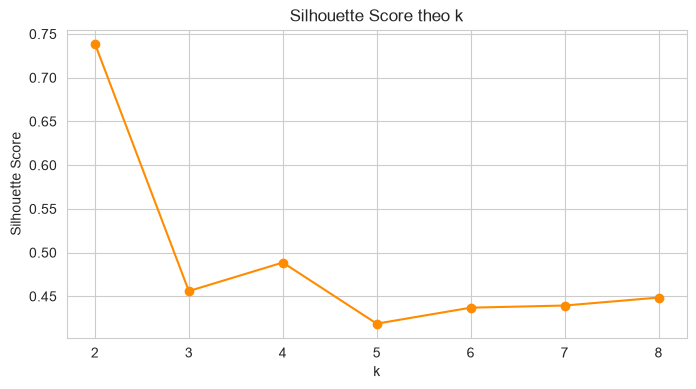

In [7]:
silhouette_scores = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f'k={k} -> silhouette={score:.4f}')

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f'\nk tot nhat theo silhouette: {best_k}')

plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='darkorange')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score theo k')
plt.show()

## 5. KMeans — fit model cuối
**Quan trọng:** silhouette score chọn k tối ưu về mặt THỐNG KÊ THUẦN TÚY, không phải k tối ưu
về mặt BUSINESS. Với dataset này, silhouette ủng hộ k=2 (0.74) rất mạnh so với k=4 (0.49) —
vì ~97% khách hàng chỉ mua 1 lần, nên tách 2 nhóm tự nhiên nhất chỉ đơn giản là "mua 1 lần" vs
"mua nhiều lần". Nhưng k=2 gộp mất sự khác biệt quan trọng cho marketing: nhóm chi tiêu rất cao
(dù chỉ mua 1 lần) sẽ bị gộp chung với nhóm chi tiêu thấp cũng chỉ mua 1 lần — mất đúng thông tin
cần để ưu tiên ngân sách cross-sell.

**Quyết định:** giữ `k=4` theo `N_CLUSTERS` trong `config.ini` (khớp với production pipeline
chạy qua `python main.py` / `src.segmentation.py`), KHÔNG dùng `best_k` (silhouette-optimal) làm
`FINAL_K` — đây là quyết định business, không phải bug hay sự bất cẩn.

> *"Although silhouette analysis favored k=2, we retained k=4 because the four-cluster solution
> provided more actionable customer differentiation for marketing strategy."*

In [8]:
from src.config import N_CLUSTERS

print(f'Best k by Silhouette:        {best_k}  (silhouette={silhouette_scores[best_k]:.4f})')
print(f'Business-selected k (config): {N_CLUSTERS}  (silhouette={silhouette_scores.get(N_CLUSTERS, float("nan")):.4f})')

FINAL_K = N_CLUSTERS  # dung dung tham so production, KHONG dung best_k
print(f'Final k used for segmentation: {FINAL_K}')

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
rfm['cluster'] = kmeans_final.fit_predict(X_scaled)

final_score = silhouette_score(X_scaled, rfm['cluster'])
print(f'\nFINAL_K = {FINAL_K}, Silhouette = {final_score:.4f}, Inertia = {kmeans_final.inertia_:.2f}')

Best k by Silhouette:        2  (silhouette=0.7389)
Business-selected k (config): 4  (silhouette=0.4886)
Final k used for segmentation: 4

FINAL_K = 4, Silhouette = 0.4886, Inertia = 92099.17


## 6. Cluster Statistics

In [9]:
cluster_stats = rfm.groupby('cluster')[FEATURE_COLUMNS].agg(['mean', 'median', 'std'])
cluster_stats['count'] = rfm.groupby('cluster').size()
cluster_stats

recency_days                    frequency                   \
                mean median         std      mean median       std   
cluster                                                              
0         387.408517  374.0   96.133387  1.000000    1.0  0.000000   
1         220.443723  199.0  143.707849  2.114358    2.0  0.505027   
2         239.397849  225.0  150.910873  1.012821    1.0  0.123060   
3         128.074365  129.0   72.227809  1.000000    1.0  0.000000   

            monetary                      count  
                mean  median         std         
cluster                                          
0         133.457760  101.34  107.745458  37526  
1         289.680253  223.90  225.114619   2772  
2        1160.906344  935.94  674.488678   2418  
3         134.360030  103.64  106.993551  50642

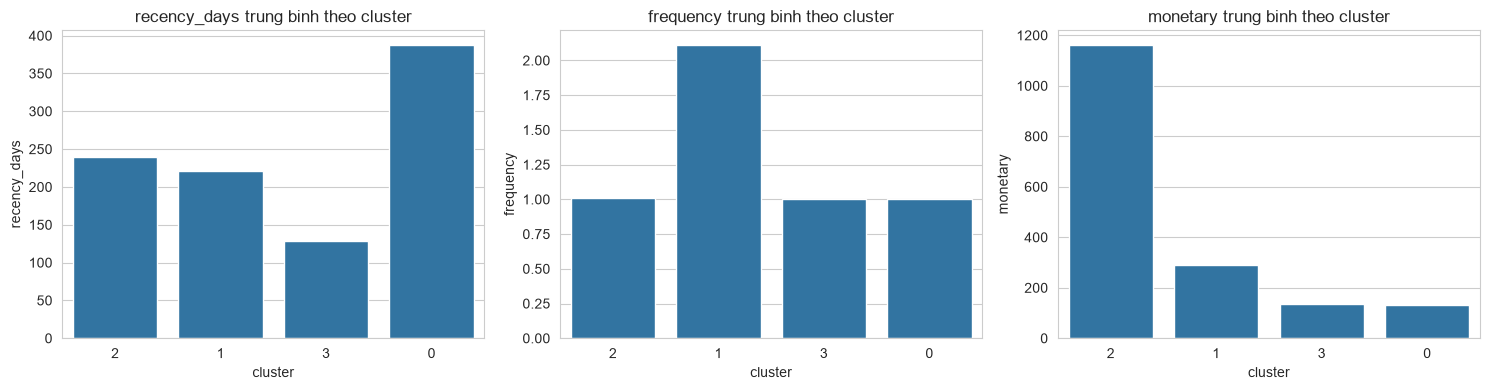

In [10]:
profile = rfm.groupby('cluster')[FEATURE_COLUMNS].mean().round(2)
profile['count'] = rfm.groupby('cluster').size()
profile = profile.sort_values('monetary', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, FEATURE_COLUMNS):
    sns.barplot(x=profile.index.astype(str), y=profile[col], ax=ax, order=profile.index.astype(str))
    ax.set_title(f'{col} trung binh theo cluster')
plt.tight_layout()
plt.show()

## 7. Radar Chart — so sánh cluster trên cả 3 chiều RFM cùng lúc
Bar chart riêng lẻ (ở trên) chỉ so sánh từng chỉ số 1 lần — radar chart cho phép nhìn "hình dạng"
tổng thể của mỗi cluster trên cả 3 trục cùng lúc, trực quan hơn khi trình bày với business.

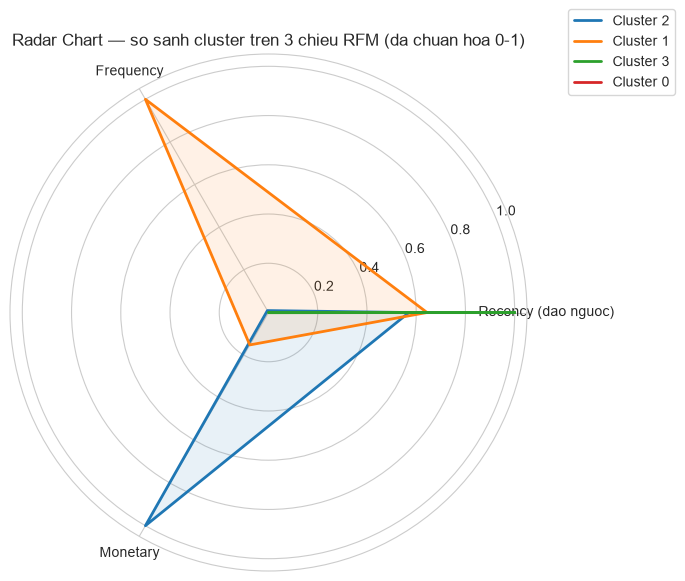

In [11]:
# Chuan hoa ve thang 0-1 de ve tren cung 1 radar chart (Recency dao nguoc vi thap = tot)
radar_df = profile[FEATURE_COLUMNS].copy()
radar_df['recency_days'] = radar_df['recency_days'].max() - radar_df['recency_days']  # dao nguoc: cao hon = tot hon
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

labels = ['Recency (dao nguoc)', 'Frequency', 'Monetary']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cluster_id in radar_norm.index:
    values = radar_norm.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title('Radar Chart — so sanh cluster tren 3 chieu RFM (da chuan hoa 0-1)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

**Cách đọc radar chart:** cluster nào có diện tích lớn nhất (bao phủ cả 3 trục) chính là nhóm
khách hàng tốt nhất theo tổng hợp cả 3 tiêu chí (`Loyal Customers` trong dataset này — Recency
thấp/gần đây, Frequency cao, Monetary cao). Cluster có diện tích nhỏ nhất, lệch hẳn về 1 phía là
nhóm cần chú ý nhất (`Dormant Customers`).

**Lưu ý:** với dataset này, cluster có Monetary trung bình cao NHẤT (`High-Value Potential`) không
phải cluster có diện tích radar lớn nhất — vì Frequency của nhóm đó rất thấp (~1, gần như chỉ mua
1 lần). Đây chính là phát hiện quan trọng dẫn đến việc đổi tên `High-Value Loyal` → `Loyal Customers`
và `Potential Loyal` → `High-Value Potential` (xem `src/export_segments.py` docstring để biết chi tiết).

## 8. PCA Visualization
RFM chỉ có 3 chiều nên PCA không thật sự cần thiết để "giảm chiều", nhưng hữu ích để visualize
cluster trên 1 mặt phẳng 2D duy nhất.

Ty le phuong sai giai thich duoc boi 2 PC: 0.7078


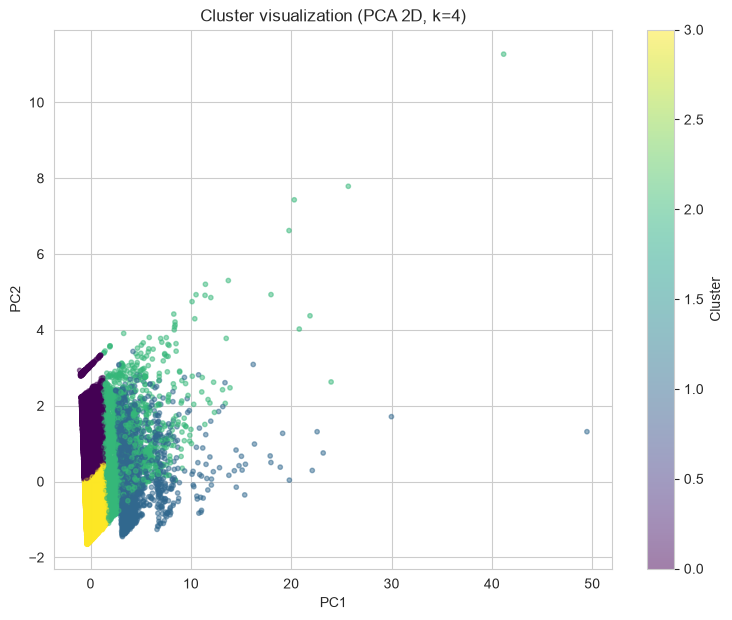

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print('Ty le phuong sai giai thich duoc boi 2 PC:', pca.explained_variance_ratio_.sum().round(4))

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm['cluster'], cmap='viridis', s=10, alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Cluster visualization (PCA 2D, k={FINAL_K})')
plt.colorbar(scatter, label='Cluster')
plt.show()

## 9. Đặt tên từng cluster (Business Interpretation)
Logic đặt tên giống hệt `src/export_segments.py` (rank-based theo Recency/Frequency/Monetary).

In [13]:
from src.export_segments import label_clusters

rfm_named = label_clusters(rfm.copy())
rfm_named.groupby('segment_name')[FEATURE_COLUMNS].mean().round(2)

2026-08-09 20:10:37 | INFO     | src.export_segments | Cluster -> segment name mapping: {1: 'Loyal Customers', 2: 'High-Value Potential', 3: 'Active One-Time Customers', 0: 'Dormant Customers'}


,recency_days,frequency,monetary
segment_name,,,
Active One-Time Customers,128.07,1.00,134.36
Dormant Customers,387.41,1.00,133.46
High-Value Potential,239.40,1.01,1160.91
Loyal Customers,220.44,2.11,289.68


| Segment | Đặc điểm (dữ liệu thật) | Hành động đề xuất |
|---|---|---|
| Loyal Customers | Frequency cao nhất (2.11), Monetary vừa phải (289.68) | VIP Campaign / loyalty program |
| High-Value Potential | Monetary cao nhất (1,160.91), Frequency thấp (~1.01) | Cross-sell / khuyến khích mua lần 2 |
| Active One-Time Customers | Recency thấp nhất (128.07 — mới mua gần đây), Frequency=1 | Second-purchase / conversion campaign |
| Dormant Customers | Recency cao nhất (387.41), Frequency=1, Monetary thấp | Win-back chi phí thấp / giảm ưu tiên ngân sách |

**Lưu ý quan trọng:** tên gọi này là *business interpretation* dựa trên bảng cluster-level RFM
thật của dataset này (xem `src/export_segments.py` docstring) — không phải tên tự sinh ra từ
KMeans. Nếu dataset thay đổi, cần re-verify lại mapping này, không mặc định giữ nguyên.

## 10. Business Recommendation cho từng cluster
Gọi thẳng `src/recommendation.py` — cùng 1 rule dùng lại ở `04_business_analysis.ipynb`,
không viết lại recommendation text ở nhiều chỗ.

In [14]:
from src.recommendation import generate_recommendations

recs = generate_recommendations(rfm_named)
for segment, rec in recs.items():
    print(f'=== {segment} ===')
    print(rec)
    print()

2026-08-09 20:10:37 | INFO     | src.recommendation | Generated recommendations for 4 segments.


=== Active One-Time Customers ===
Chiếm tỷ trọng khách hàng lớn nhất, mới mua gần đây (recency thấp nhất trong 4 nhóm) nhưng đều là mua lần đầu (frequency=1) — KHÔNG có bằng chứng đây là khách từng loyal rồi suy giảm, nên đây là nhóm 'cơ hội chuyển đổi' chứ không phải 'rủi ro mất khách'. Ưu tiên chiến dịch khuyến khích đơn hàng thứ 2 (second-purchase incentive), welcome-back offer trong khung thời gian ngắn sau đơn đầu tiên.

=== Dormant Customers ===
Recency rất cao (lâu nhất trong 4 nhóm, gấp ~3 lần Active One-Time), frequency/monetary thấp. Chưa đủ cơ sở khẳng định 'mất hẳn' (dataset chỉ có ~2 năm dữ liệu), nên gọi 'Dormant' thay vì 'Lost'. Cân nhắc chiến dịch win-back chi phí thấp (email reactivation); nếu không phản hồi sau vài đợt, giảm ưu tiên ngân sách marketing cho nhóm này.

=== Loyal Customers ===
Frequency cao nhất trong 4 segment (đặt lại đơn nhiều lần), dù chi tiêu trung bình mỗi đơn không phải cao nhất. Ưu tiên VIP Campaign / chương trình loyalty: giữ chân nhóm đã chứng 

---
## Quyết định rút ra từ notebook này
- k đã chọn: **4** (business-selected, không theo silhouette-optimal k=2 — xem giải thích ở mục 5)
- Silhouette Score tại k=4: **0.4886** (thấp hơn k=2 là 0.7389, nhưng chấp nhận được để đổi lấy
  khả năng phân biệt segment có ý nghĩa business)
- `N_CLUSTERS` trong `config.ini` giữ nguyên = 4, khớp với production pipeline
- Cluster "tốt nhất" theo radar chart: `Loyal Customers` (cluster 1) — nhưng KHÔNG phải cluster có
  Monetary cao nhất, đó là `High-Value Potential` (cluster 2) — 2 khái niệm "tốt" khác nhau (loyalty
  vs. spend), cần phân biệt rõ khi trình bày business